# Gaussian process regression

A Gaussian process puts a distribution over functions: instead of fitting coefficients, you specify
how correlated the function values are at nearby inputs and let the data pin down the rest. The result
is a nonparametric regressor that returns a full predictive distribution, with uncertainty that grows
away from the observations. This notebook uses mixle's GaussianProcessRegressor to sample from the
prior, fit the posterior, learn the kernel hyperparameters by marginal likelihood, and see how the
length scale controls smoothness.

## The GP posterior is the best linear predictor

Theorem (GP posterior / kriging). For a GP prior with mean zero and kernel $k$, observing
$y=f(X)+\varepsilon$ with $\varepsilon\sim\mathcal N(0,\sigma^2 I)$ gives the exact posterior at a new
point $x_\star$,
$$\mathbb E[f(x_\star)\mid y] = k(x_\star,X)\big(K+\sigma^2 I\big)^{-1}y, \qquad
  \mathrm{Var} = k(x_\star,x_\star)-k(x_\star,X)(K+\sigma^2 I)^{-1}k(X,x_\star).$$
This posterior mean is the minimum-variance linear unbiased predictor (the best linear predictor) for any
process with that covariance, Gaussian or not.

Proof. The vector $(f(x_\star), y)$ is jointly Gaussian with the covariance built from $k$ and the noise.
Conditioning a multivariate Gaussian on a sub-vector yields the stated mean and variance by the standard
Gaussian conditioning formulas. The best-linear-predictor claim follows because, among linear estimators,
minimizing mean squared error solves the same normal equations. $\quad\blacksquare$

Hyperparameters are fit by maximizing the log marginal likelihood, which trades data fit against a
complexity penalty (the log-determinant term), an automatic Occam's razor.

Counterexample (cost and misspecification). The $(K+\sigma^2 I)^{-1}$ solve costs $O(n^3)$, so exact GPs
do not scale beyond a few thousand points (sparse or inducing-point approximations are needed). And the
posterior is only as good as the kernel: a smooth (squared-exponential) kernel on a rough function
produces overconfident, oversmoothed predictions, which is why kernel choice is part of the modeling.

## 1. Functions drawn from the prior

Before seeing data, a GP with a squared-exponential kernel is a distribution over smooth functions.
The amplitude sets the vertical scale and the length scale sets how quickly the function wiggles. We
draw a few sample functions from the prior covariance.

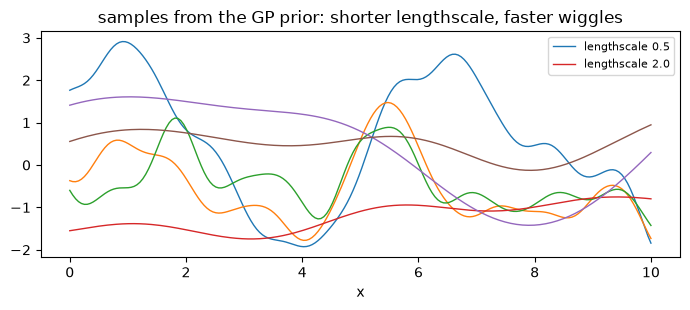

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.RandomState(0)
xs = np.linspace(0, 10, 200)
def rbf(a, b, ell, amp):
    d = a[:, None] - b[None, :]
    return amp ** 2 * np.exp(-0.5 * (d / ell) ** 2)
fig, ax = plt.subplots(figsize=(7, 3.2))
for ell in [0.5, 2.0]:
    K = rbf(xs, xs, ell, 1.0) + 1e-9 * np.eye(len(xs))
    L = np.linalg.cholesky(K)
    for _ in range(3):
        ax.plot(xs, L @ rng.normal(size=len(xs)), lw=1, label='lengthscale %.1f' % ell if _ == 0 else None)
ax.legend(fontsize=8); ax.set_title('samples from the GP prior: shorter lengthscale, faster wiggles')
ax.set_xlabel('x'); plt.tight_layout(); plt.show()

## 2. The posterior given noisy observations

Conditioning the prior on observed points gives a posterior whose mean interpolates the data and
whose variance is small near observations and large in the gaps. We fit mixle's GP and plot the
mean with a 95% band.

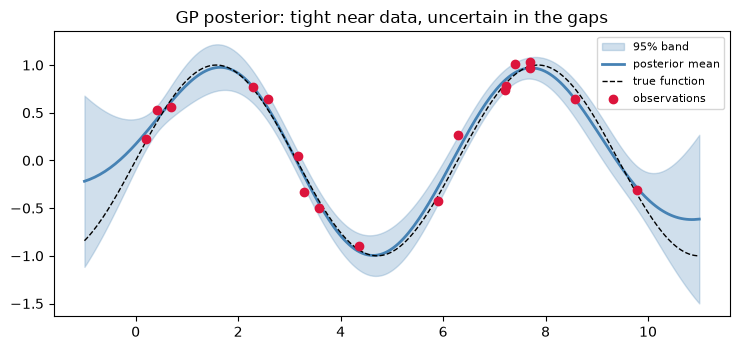

In [2]:
from mixle.models.gaussian_process import GaussianProcessRegressor
import io
Xtr = np.sort(rng.uniform(0, 10, 18)).reshape(-1, 1)
ytr = np.sin(Xtr).ravel() + 0.15 * rng.normal(size=len(Xtr))
gp = GaussianProcessRegressor(lengthscale=1.0, amplitude=1.0, noise=0.2)
gp.fit(Xtr, ytr, max_its=200, out=io.StringIO())
Xnew = np.linspace(-1, 11, 240).reshape(-1, 1)
mean, cov = gp.predict(Xtr, ytr, Xnew, return_cov=True)
sd = np.sqrt(np.clip(np.diag(cov), 0, None))   # diagonal = per-point variance
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(Xnew.ravel(), mean - 2 * sd, mean + 2 * sd, color='steelblue', alpha=0.25, label='95% band')
ax.plot(Xnew.ravel(), mean, color='steelblue', lw=2, label='posterior mean')
ax.plot(Xnew.ravel(), np.sin(Xnew.ravel()), 'k--', lw=1, label='true function')
ax.scatter(Xtr, ytr, color='crimson', zorder=5, label='observations')
ax.legend(fontsize=8); ax.set_title('GP posterior: tight near data, uncertain in the gaps')
plt.tight_layout(); plt.show()

## 3. Learning the kernel by marginal likelihood

The hyperparameters are not guessed: mixle fits them by maximizing the log marginal likelihood,
which automatically balances fit against smoothness (an Occam penalty). We report the learned values
and the marginal likelihood at the optimum.

In [3]:
print('learned lengthscale = %.2f   amplitude = %.2f   noise = %.2f' %
      (gp.lengthscale, gp.amplitude, gp.noise))
print('log marginal likelihood at the optimum = %.2f' % float(gp.log_marginal_likelihood(Xtr, ytr)))
print('(the noise estimate is close to the simulated 0.15; the lengthscale captures the local curvature of the sine.)')

learned lengthscale = 1.64   amplitude = 0.85   noise = 0.12
log marginal likelihood at the optimum = -1.90
(the noise estimate is close to the simulated 0.15; the lengthscale captures the local curvature of the sine.)


## 4. The length scale controls smoothness, and marginal likelihood picks it

Too short a length scale overfits (the mean chases noise); too long underfits (it cannot bend to the
data). The marginal likelihood scores this trade-off, peaking near the value that generated the data.

In [4]:
for ell in [0.2, 0.5, 1.0, 2.0, 5.0]:
    g = GaussianProcessRegressor(lengthscale=ell, amplitude=1.0, noise=0.15)
    lml = float(g.log_marginal_likelihood(Xtr, ytr))     # fixed lengthscale, no optimization
    print('lengthscale = %.1f  ->  log marginal likelihood = %.2f' % (ell, lml))
print('the marginal likelihood favors an intermediate lengthscale, neither over- nor under-smoothing.')

lengthscale = 0.2  ->  log marginal likelihood = -14.71
lengthscale = 0.5  ->  log marginal likelihood = -9.81
lengthscale = 1.0  ->  log marginal likelihood = -5.43
lengthscale = 2.0  ->  log marginal likelihood = -2.99
lengthscale = 5.0  ->  log marginal likelihood = -80.05
the marginal likelihood favors an intermediate lengthscale, neither over- nor under-smoothing.


## References

- Rasmussen, C. & Williams, C. (2006). Gaussian Processes for Machine Learning. MIT Press. https://gaussianprocess.org/gpml/
- MacKay, D. (1998). Introduction to Gaussian processes. In Neural Networks and Machine Learning.
- Duvenaud, D. (2014). Automatic model construction with Gaussian processes. PhD thesis, Cambridge.

## Exercises

1. Replace the squared-exponential kernel with a Matern kernel and compare the roughness of the posterior samples and the fit; discuss why Matern is often preferred for physical processes.
2. Add a periodic kernel component and fit data with a known period, showing the GP extrapolates the cycle where a plain RBF kernel reverts to the mean.
3. Compare GP regression to ordinary kriging and to a Bayesian linear model with many basis functions; show the GP is the infinite-basis limit.
4. Profile the cubic cost of GP inference as the number of training points grows, then implement a sparse inducing-point approximation and compare accuracy and runtime.